In [2]:
# Phần 1: Quy trình Tiền xử lý Dữ liệu Chuẩn 4 Bước
!pip install underthesea
import re
from underthesea import word_tokenize

# Văn bản tiếng Việt mẫu
sample_text = """
Trí tuệ nhân tạo (AI) đang phát triển vô cùng mạnh mẽ trên toàn thế giới.
Các công nghệ tiên tiến như Học máy và Học sâu đang làm thay đổi cách con người làm việc.
Xử lý ngôn ngữ tự nhiên là một nhánh quan trọng của trí tuệ nhân tạo.
Nó giúp máy tính hiểu, phân tích và tạo ra ngôn ngữ tự nhiên của con người.
Việc ứng dụng AI vào các lĩnh vực như y tế, giáo dục và tài chính mang lại hiệu quả rất cao.
Tuy nhiên, phát triển AI cũng đặt ra nhiều thách thức về đạo đức và bảo mật dữ liệu.
"""

VIETNAMESE_STOPWORDS = set([
    "và", "hoặc", "nhưng", "vì", "nên", "bởi", "tại", "trong", "ngoài", "trên",
    "dưới", "những", "các", "mọi", "mỗi", "một", "hai", "là", "có", "được", "bị",
    "cho", "với", "theo", "đến", "từ", "này", "đó", "khi", "như", "để", "ra"
])

# BƯỚC 1: TÁCH CÂU
def step1_split_sentences(text):
    sentences = re.split(r'(?<=[.!?])\s+|\n+', text)
    return [s.strip() for s in sentences if len(s.strip()) > 10]

# BƯỚC 2: TÁCH TỪ (Word Tokenization)
def step2_word_tokenize(sentence):
    return word_tokenize(sentence, format="text")

# BƯỚC 3: TIỀN XỬ LÝ (Làm sạch & Chuẩn hóa)
def step3_clean_text(tokenized_sentence):
    lowered = tokenized_sentence.lower()
    cleaned = re.sub(r'[^\w\s_]', '', lowered) # Loại bỏ dấu câu/ký tự đặc biệt
    words = cleaned.split()
    return [w for w in words if w.isalnum()]

# BƯỚC 4: LOẠI BỎ TỪ DỪNG
def step4_remove_stopwords(words_list):
    return [w for w in words_list if w not in VIETNAMESE_STOPWORDS]

# TỔNG HỢP QUY TRÌNH TIỀN XỬ LÝ
def full_preprocessing_pipeline(text):
    raw_sentences = step1_split_sentences(text)
    processed_sentences = []

    for sent in raw_sentences:
        tok_sent = step2_word_tokenize(sent)
        clean_words = step3_clean_text(tok_sent)
        final_words = step4_remove_stopwords(clean_words)
        processed_sentences.append(final_words)

    return raw_sentences, processed_sentences

# Chạy thử nghiệm quy trình
raw_sents, proc_sents = full_preprocessing_pipeline(sample_text)

print("=== KIỂM TRA QUY TRÌNH TIỀN XỬ LÝ 4 BƯỚC ===")
for i in range(len(raw_sents)):
    print(f"\n[Câu {i+1} Gốc]: {raw_sents[i]}")
    print(f" -> Sau B1-B4 (Tokens cuối): {proc_sents[i]}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 41.2 MB/s eta 0:00:00
=== KIỂM TRA QUY TRÌNH TIỀN XỬ LÝ 4 BƯỚC ===

[Câu 1 Gốc]: Trí tuệ nhân tạo (AI) đang phát triển vô cùng mạnh mẽ trên toàn thế giới.
 -> Sau B1-B4 (Tokens cuối): ['ai', 'đang', 'toàn']

[Câu 2 Gốc]: Các công nghệ tiên tiến như Học máy và Học sâu đang làm thay đổi cách con người làm việc.
 -> Sau B1-B4 (Tokens cuối): ['học', 'sâu', 'đang', 'làm', 'cách']

[Câu 3 Gốc]: Xử lý ngôn ngữ tự nhiên là một nhánh quan trọng của trí tuệ nhân tạo.
 -> Sau B1-B4 (Tokens cuối): ['nhánh', 'của']

[Câu 4 Gốc]: Nó giúp máy tính hiểu, phân tích và tạo ra ngôn ngữ tự nhiên của con người.
 -> Sau B1-B4 (Tokens cuối): ['nó', 'giúp', 'hiểu', 'tạo', 'của']

[Câu 5 Gốc]: Việc ứng dụng AI vào các lĩnh vực như y tế, giáo dục và tài chính mang lại hiệu quả rất cao.
 -> Sau B1-B4 (Tokens cuối): ['việc', 'ai', 'vào', 'mang', 'lại', 'rất', 'cao']

[Câu 6 Gốc]: Tuy

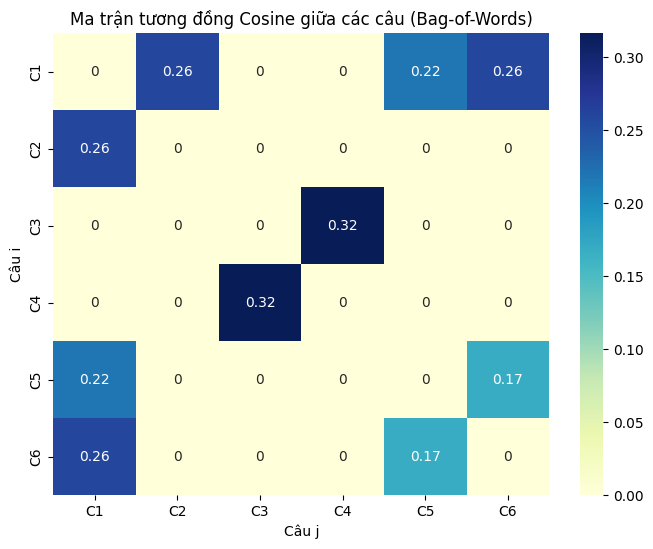

In [3]:
# Phần 2: Ma trận Tương đồng & Heatmap Visualizer
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def cosine_similarity(tokens1, tokens2):
    vocab = list(set(tokens1) | set(tokens2))
    if not vocab:
        return 0.0
    v1 = np.array([tokens1.count(w) for w in vocab])
    v2 = np.array([tokens2.count(w) for w in vocab])
    norm = np.linalg.norm(v1) * np.linalg.norm(v2)
    return np.dot(v1, v2) / norm if norm > 0 else 0.0

n = len(raw_sents)
sim_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i != j:
            sim_matrix[i][j] = cosine_similarity(proc_sents[i], proc_sents[j])

plt.figure(figsize=(8, 6))
sns.heatmap(sim_matrix, annot=True, cmap="YlGnBu", xticklabels=[f"C{i+1}" for i in range(n)], yticklabels=[f"C{i+1}" for i in range(n)])
plt.title("Ma trận tương đồng Cosine giữa các câu (Bag-of-Words)")
plt.xlabel("Câu j")
plt.ylabel("Câu i")
plt.show()

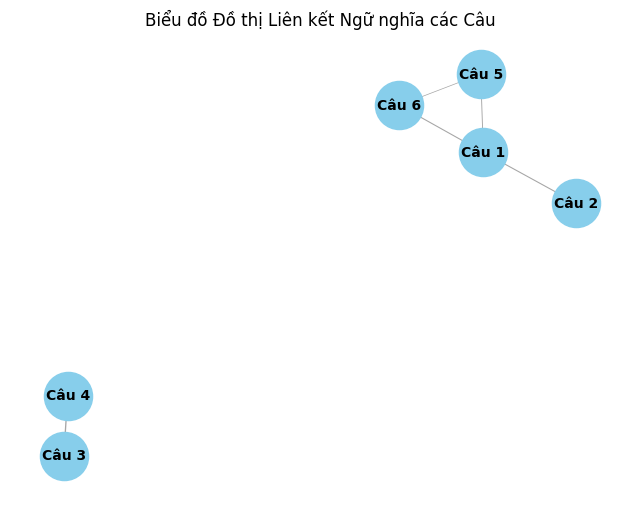

In [4]:
# Phần 3: Trực quan hóa Biểu đồ Đồ thị NetworkX
import networkx as nx

nx_graph = nx.from_numpy_array(sim_matrix)

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(nx_graph, seed=42)

nx.draw_networkx_nodes(nx_graph, pos, node_color='skyblue', node_size=1200)
nx.draw_networkx_labels(nx_graph, pos, labels={i: f"Câu {i+1}" for i in range(n)}, font_size=10, font_weight="bold")

edges = [(u, v) for (u, v, d) in nx_graph.edges(data=True) if d['weight'] > 0.1]
weights = [nx_graph[u][v]['weight'] * 3 for u, v in edges]
nx.draw_networkx_edges(nx_graph, pos, edgelist=edges, width=weights, edge_color='gray', alpha=0.7)

plt.title("Biểu đồ Đồ thị Liên kết Ngữ nghĩa các Câu")
plt.axis('off')
plt.show()

=== BẢNG XẾP HẠNG ĐIỂM PAGERANK (d = 0.85) ===
Hạng 1 [PR: 0.2624] - Câu 1: Trí tuệ nhân tạo (AI) đang phát triển vô cùng mạnh mẽ trên toàn thế giới.
Hạng 2 [PR: 0.1667] - Câu 4: Nó giúp máy tính hiểu, phân tích và tạo ra ngôn ngữ tự nhiên của con người.
Hạng 3 [PR: 0.1667] - Câu 3: Xử lý ngôn ngữ tự nhiên là một nhánh quan trọng của trí tuệ nhân tạo.
Hạng 4 [PR: 0.1568] - Câu 6: Tuy nhiên, phát triển AI cũng đặt ra nhiều thách thức về đạo đức và bảo mật dữ liệu.
Hạng 5 [PR: 0.1440] - Câu 5: Việc ứng dụng AI vào các lĩnh vực như y tế, giáo dục và tài chính mang lại hiệu quả rất cao.
Hạng 6 [PR: 0.1034] - Câu 2: Các công nghệ tiên tiến như Học máy và Học sâu đang làm thay đổi cách con người làm việc.


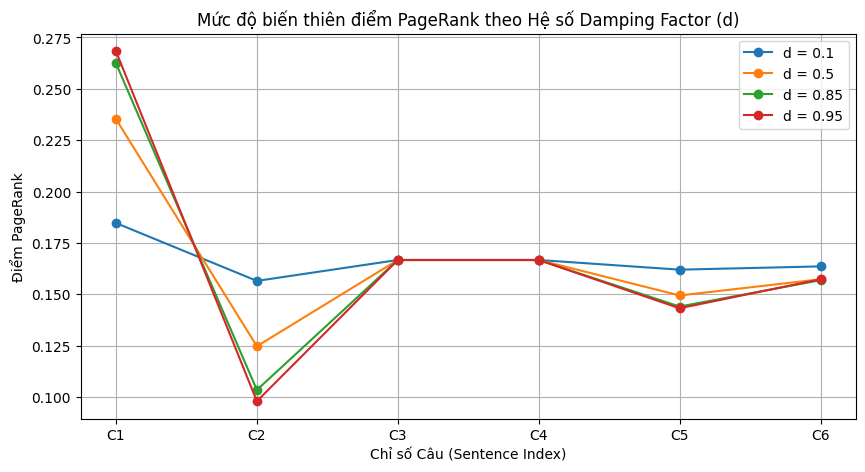

In [5]:
# Phần 4: Chạy PageRank & Đánh giá Damping Factor (d)
scores = nx.pagerank(nx_graph, alpha=0.85)
ranked_sentences = sorted(((scores[i], i, raw_sents[i]) for i in range(n)), reverse=True)

print("=== BẢNG XẾP HẠNG ĐIỂM PAGERANK (d = 0.85) ===")
for rank, (score, idx, sent) in enumerate(ranked_sentences):
    print(f"Hạng {rank+1} [PR: {score:.4f}] - Câu {idx+1}: {sent}")

# Thực nghiệm thay đổi hệ số d
d_values = [0.1, 0.5, 0.85, 0.95]
plt.figure(figsize=(10, 5))

for d in d_values:
    pr = nx.pagerank(nx_graph, alpha=d)
    plt.plot(list(pr.keys()), list(pr.values()), marker='o', label=f'd = {d}')

plt.xlabel("Chỉ số Câu (Sentence Index)")
plt.ylabel("Điểm PageRank")
plt.title("Mức độ biến thiên điểm PageRank theo Hệ số Damping Factor (d)")
plt.xticks(range(n), [f"C{i+1}" for i in range(n)])
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# Phần 5: Thực nghiệm Nâng cao với Transformer (Sentence-BERT)
from sentence_transformers import SentenceTransformer

# Tải Pre-trained Transformer Model chuyên cho tiếng Việt
transformer_model = SentenceTransformer('bkai-foundation-models/vietnamese-bi-encoder')

# Tạo Vector Embeddings cho từng câu gốc
embeddings = transformer_model.encode(raw_sents)

# Tính Ma trận Cosine Similarity dựa trên Transformer Embeddings
embed_sim_matrix = np.inner(embeddings, embeddings)
norms = np.linalg.norm(embeddings, axis=1)
embed_sim_matrix = embed_sim_matrix / np.outer(norms, norms)
np.fill_diagonal(embed_sim_matrix, 0) # Xóa đường chéo chính

# Chạy PageRank trên ma trận Transformer
embed_graph = nx.from_numpy_array(embed_sim_matrix)
embed_scores = nx.pagerank(embed_graph, alpha=0.85)

print("=== SO SÁNH ĐIỂM PAGERANK: BAG-OF-WORDS VS TRANSFORMER (SENTENCE-BERT) ===")
for i in range(n):
    print(f"Câu {i+1}: BoW PR = {scores[i]:.4f} | Transformer PR = {embed_scores[i]:.4f}")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/6.46k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/22.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

=== SO SÁNH ĐIỂM PAGERANK: BAG-OF-WORDS VS TRANSFORMER (SENTENCE-BERT) ===
Câu 1: BoW PR = 0.2624 | Transformer PR = 0.2090
Câu 2: BoW PR = 0.1034 | Transformer PR = 0.1417
Câu 3: BoW PR = 0.1667 | Transformer PR = 0.1505
Câu 4: BoW PR = 0.1667 | Transformer PR = 0.1405
Câu 5: BoW PR = 0.1440 | Transformer PR = 0.1887
Câu 6: BoW PR = 0.1568 | Transformer PR = 0.1695
